# Overview

In this notebook, we investigate the Accelerated ADMM methods and the IQC framework proposed in the paper.  
To evaluate performance, we apply a bisection search to solve the semidefinite program (SDP) derived from **Theorem 2** in the paper, enabling a direct comparison of the worst-case convergence rates between our proposed method and several benchmark algorithms.

The bisection procedure is implemented in the helper code `convergence_analysis`, which computes the worst-case rate $\rho$ for each algorithm under consideration.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lib.convergence_analysis import compute_rho_for_acc_admm
from lib.grid_search import load_results


In [25]:
kappas = np.logspace(0, 3, 20)
n_ZF_list = [1, 2, 5]
n_ZF = 5
rho_max= 1.3
eps= 1e-6
alpha= 1.4

## Fig.1

[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=1.00, ρ=0.5002
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=1.44, ρ=0.5434
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=2.07, ρ=0.5872
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=2.98, ρ=0.6329
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=4.28, ρ=0.6735
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=6.16, ρ=0.7217
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=8.86, ρ=0.7871
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=12.74, ρ=0.8480
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=18.33, ρ=0.9014
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=26.37, ρ=0.9464
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=37.93, ρ=0.9852
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=54.56, ρ=1.0169
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=78.48, ρ=1.0442
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=112.88, ρ=1.0664
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=162.38, ρ=1.0848
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=233.57, ρ=1.1058
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=335.98, ρ=1.1299
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=483.29, ρ=1.1527
[INFO] algo='A-ADMM (NM)', n_ZF=1, κ=695.19, ρ=1

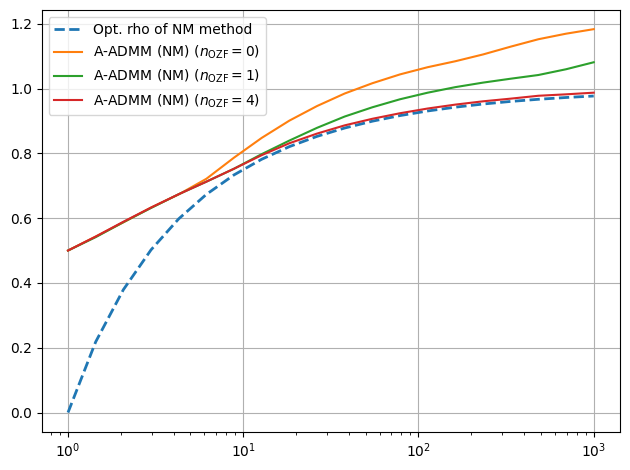

In [21]:
rhos_by_n_ZF = {}

for n_ZF in n_ZF_list:
    rhos = []

    for kappa in kappas:
        rho = compute_rho_for_acc_admm(
            1, kappa,
            n_ZF,
            algo='A-ADMM (NM)',
            rho_max=1.3,
            eps=1e-6,
            alpha=alpha
        )

        print(f"[INFO] algo='A-ADMM (NM)', n_ZF={n_ZF}, κ={kappa:.2f}, ρ={rho:.4f}")
        rhos.append(rho)

    rhos_by_n_ZF[n_ZF] = rhos


rhos_NM_Lit_all = [
    np.sqrt(1 - (1 / kappa) * np.sqrt(2 * kappa - 1))
    for kappa in kappas
]


plt.xscale('log')
plt.grid(True)

plt.plot(
    kappas,
    rhos_NM_Lit_all,
    label='Opt. rho of NM method',
    linewidth=2,
    linestyle='--'
)

for n_ZF, rhos in rhos_by_n_ZF.items():
    plt.plot(
        kappas,
        rhos,
        label=f"A-ADMM (NM) ($n_{{\\mathrm{{OZF}}}} = {n_ZF-1}$)"
    )

plt.legend()
plt.tight_layout()
plt.show()

## Fig.3

[INFO] algo=ADMM, kappa=1.00, rho=0.5002
[INFO] algo=ADMM, kappa=1.44, rho=0.5434
[INFO] algo=ADMM, kappa=2.07, rho=0.5891
[INFO] algo=ADMM, kappa=2.98, rho=0.6322
[INFO] algo=ADMM, kappa=4.28, rho=0.6741
[INFO] algo=ADMM, kappa=6.16, rho=0.7128
[INFO] algo=ADMM, kappa=8.86, rho=0.7484
[INFO] algo=ADMM, kappa=12.74, rho=0.7814
[INFO] algo=ADMM, kappa=18.33, rho=0.8106
[INFO] algo=ADMM, kappa=26.37, rho=0.8373
[INFO] algo=ADMM, kappa=37.93, rho=0.8607
[INFO] algo=ADMM, kappa=54.56, rho=0.8811
[INFO] algo=ADMM, kappa=78.48, rho=0.8988
[INFO] algo=ADMM, kappa=112.88, rho=0.9141
[INFO] algo=ADMM, kappa=162.38, rho=0.9274
[INFO] algo=ADMM, kappa=233.57, rho=0.9388
[INFO] algo=ADMM, kappa=335.98, rho=0.9483
[INFO] algo=ADMM, kappa=483.29, rho=0.9566
[INFO] algo=ADMM, kappa=695.19, rho=0.9636
[INFO] algo=ADMM, kappa=1000.00, rho=0.9699
[INFO] algo=A-ADMM (NM), kappa=1.00, rho=0.5002
[INFO] algo=A-ADMM (NM), kappa=1.44, rho=0.5434
[INFO] algo=A-ADMM (NM), kappa=2.07, rho=0.5891
[INFO] algo=A-A

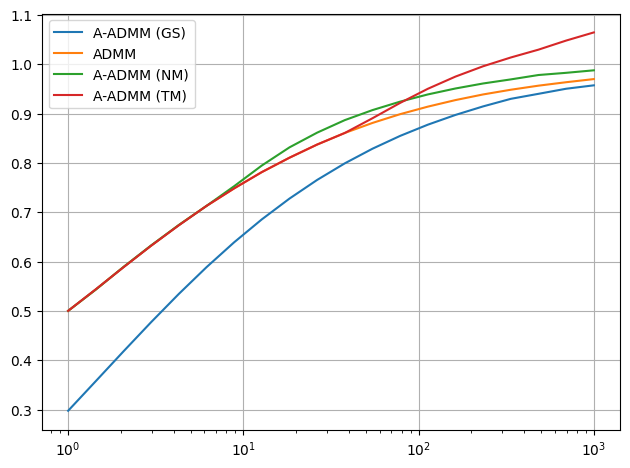

In [26]:
algos = ['ADMM', 'A-ADMM (NM)', 'A-ADMM (TM)']

results = dict()

for algo in algos:
    rhos = []
    for kappa in kappas:
        rho = compute_rho_for_acc_admm(
                            1, kappa,
                            n_ZF,
                            algo=algo,
                            rho_max=1.3,
                            eps=1e-6,
                            alpha=alpha
                        )
        print(f"[INFO] algo={algo}, kappa={kappa:.2f}, rho={rho:.4f}")
        rhos.append(rho)
    results[algo] = np.array(rhos)


kappa_values, rate_GS, v1_values, v2_values = load_results("best_rates",json_filename="../results/Grid_search_results.json")

plt.xscale('log')
plt.grid(True); plt.tight_layout()
plt.plot(kappa_values, rate_GS, label="A-ADMM (GS)")
for algo in algos:
        y = results[algo] 
        plt.plot(
            kappas, y,
            label=f"{algo}"
        )
plt.legend()
plt.show()


## Fig.4

f:\IFAC-2026-Paper\src\venv\lib\site-packages\mosek\__init__.py:18617: UserWarning: Argument sub in putvarboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putvarboundlist: Incorrect array format causing data to be copied");
f:\IFAC-2026-Paper\src\venv\lib\site-packages\mosek\__init__.py:18925: UserWarning: Argument subj in putclist: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putclist: Incorrect array format causing data to be copied");
f:\IFAC-2026-Paper\src\venv\lib\site-packages\mosek\__init__.py:18349: UserWarning: Argument sub in putconboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putconboundlist: Incorrect array format causing data to be copied");


[INFO] algo=ADMM, kappa=1.00, rho=0.5002
[INFO] algo=ADMM, kappa=1.44, rho=0.5453
[INFO] algo=ADMM, kappa=2.07, rho=0.5897
[INFO] algo=ADMM, kappa=2.98, rho=0.6322
[INFO] algo=ADMM, kappa=4.28, rho=0.6741
[INFO] algo=ADMM, kappa=6.16, rho=0.7128
[INFO] algo=ADMM, kappa=8.86, rho=0.7490
[INFO] algo=ADMM, kappa=12.74, rho=0.7814
[INFO] algo=ADMM, kappa=18.33, rho=0.8106
[INFO] algo=ADMM, kappa=26.37, rho=0.8373
[INFO] algo=ADMM, kappa=37.93, rho=0.8607
[INFO] algo=ADMM, kappa=54.56, rho=0.8811
[INFO] algo=ADMM, kappa=78.48, rho=0.8988
[INFO] algo=ADMM, kappa=112.88, rho=0.9141
[INFO] algo=ADMM, kappa=162.38, rho=0.9274
[INFO] algo=ADMM, kappa=233.57, rho=0.9388
[INFO] algo=ADMM, kappa=335.98, rho=0.9483
[INFO] algo=ADMM, kappa=483.29, rho=0.9566
[INFO] algo=ADMM, kappa=695.19, rho=0.9636
[INFO] algo=ADMM, kappa=1000.00, rho=0.9699
[INFO] algo=OR-ADMM, kappa=1.00, rho=0.3009
[INFO] algo=OR-ADMM, kappa=1.44, rho=0.3637
[INFO] algo=OR-ADMM, kappa=2.07, rho=0.4259
[INFO] algo=OR-ADMM, kappa=

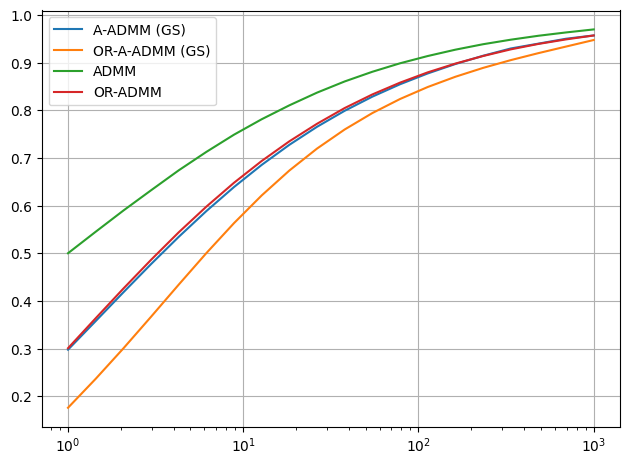

In [ ]:
algos = ['ADMM', 'OR-ADMM']
results = {
    "alg": np.zeros(len(kappas))
}
for algo in algos:
    rhos = []
    for kappa in kappas:
        rho = compute_rho_for_acc_admm(
                            1, kappa,
                            n_ZF,
                            algo=algo,
                            rho_max=1.3,
                            eps=1e-6,
                            alpha=alpha
                        )
        print(f"[INFO] algo={algo}, kappa={kappa:.2f}, rho={rho:.4f}")
        rhos.append(rho)
    results[algo] = np.array(rhos)



kappa_values, rate_GS, v1_values, v2_values = load_results("best_rates",json_filename="../results/Grid_search_results.json")
kappa_values, rate_OR_GS, v1_OR_values, v2_OR_values = load_results("OR_best_rates",json_filename="../results/Grid_search_results.json")




plt.xscale('log')
plt.grid(True); plt.tight_layout()
plt.plot(kappas, rate_GS, label="A-ADMM (GS)")
plt.plot(kappas, rate_OR_GS, label="OR-A-ADMM (GS)")
for algo in algos:
        y = results[algo] 
        plt.plot(
            kappas, y,
            label=f"{algo}"
        )
plt.legend()
plt.show()
